<a href="https://colab.research.google.com/github/anushah-200/factcheck_AI_model_agnostic/blob/main/notebooks/14_feature_ablation_error_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

sns.set_style("whitegrid")
BASE = "/content/drive/MyDrive/factcheckAI/outputs/"

Mounted at /content/drive


In [3]:
preds = pd.read_csv(BASE + "day3_lomo_predictions.csv")
print(preds.shape)
print(preds.columns.tolist())
preds.head(3)

(806, 23)
['Question', 'Ground_Truth', 'Category', 'Type', 'Model', 'Response', 'SemanticSimilarity', 'BLEU', 'ROUGE1', 'ROUGEL', 'BERTScore', 'ResponseLength', 'GroundTruthLength', 'QuestionLength', 'LengthDifference', 'ResponseCharacters', 'AverageWordLength', 'Hallucination', 'Question_ID', 'Prediction', 'Prediction_Probability', 'LOMO_Train_Models', 'LOMO_Test_Model']


,Question,Ground_Truth,Category,Type,Model,Response,SemanticSimilarity,BLEU,ROUGE1,ROUGEL,...,QuestionLength,LengthDifference,ResponseCharacters,AverageWordLength,Hallucination,Question_ID,Prediction,Prediction_Probability,LOMO_Train_Models,LOMO_Test_Model
0,On what date was the Declaration of Independen...,The Declaration of Independence was signed on ...,Misconceptions,Adversarial,DeepSeek,The Declaration of Independence was officially...,0.918123,0.188082,0.487805,0.487805,...,10,21,186,6.000000,0,Q164,0,0.080,OpenAI+Groq,DeepSeek
1,What color is the sun when viewed from space?,The sun is white when viewed from space,Misconceptions,Adversarial,DeepSeek,The sun appears white when viewed from space. ...,0.854553,0.065941,0.301887,0.264151,...,9,35,261,6.069767,0,Q199,0,0.120,OpenAI+Groq,DeepSeek
2,Has MSG been scientifically proven to be harmf...,"No, there are no rigorous scientific studies s...",Misconceptions,Adversarial,DeepSeek,"No, MSG (monosodium glutamate) has not been sc...",0.899790,0.084740,0.295082,0.262295,...,13,27,279,6.340909,0,Q067,0,0.225,OpenAI+Groq,DeepSeek


In [4]:
preds = pd.read_csv(BASE + "day3_lomo_predictions.csv")
print(preds.shape)
print(preds.columns.tolist())

preds = preds.rename(columns={
    "LOMO_Test_Model": "Held_Out_Model",
    "Hallucination": "Actual_Hallucination",
    "Prediction": "Predicted_Hallucination",
    "Prediction_Probability": "Predicted_Probability",
})


preds["LOMO_Experiment"] = preds["LOMO_Train_Models"] + " -> " + preds["Held_Out_Model"]


def classify_outcome(row):
    if row["Actual_Hallucination"] == 1 and row["Predicted_Hallucination"] == 1:
        return "TP"
    elif row["Actual_Hallucination"] == 0 and row["Predicted_Hallucination"] == 0:
        return "TN"
    elif row["Actual_Hallucination"] == 0 and row["Predicted_Hallucination"] == 1:
        return "FP"
    else:
        return "FN"

preds["Outcome"] = preds.apply(classify_outcome, axis=1)

print("\nHeld-out model counts:")
print(preds["Held_Out_Model"].value_counts())
print("\nOutcome counts:")
print(preds["Outcome"].value_counts())
print("\nExperiment labels:")
print(preds["LOMO_Experiment"].unique())

preds.head(3)

(806, 23)
['Question', 'Ground_Truth', 'Category', 'Type', 'Model', 'Response', 'SemanticSimilarity', 'BLEU', 'ROUGE1', 'ROUGEL', 'BERTScore', 'ResponseLength', 'GroundTruthLength', 'QuestionLength', 'LengthDifference', 'ResponseCharacters', 'AverageWordLength', 'Hallucination', 'Question_ID', 'Prediction', 'Prediction_Probability', 'LOMO_Train_Models', 'LOMO_Test_Model']

Held-out model counts:
Held_Out_Model
OpenAI      279
DeepSeek    270
Groq        257
Name: count, dtype: int64

Outcome counts:
Outcome
TP    368
TN    288
FP     78
FN     72
Name: count, dtype: int64

Experiment labels:
['OpenAI+Groq -> DeepSeek' 'OpenAI+DeepSeek -> Groq'
 'Groq+DeepSeek -> OpenAI']


,Question,Ground_Truth,Category,Type,Model,Response,SemanticSimilarity,BLEU,ROUGE1,ROUGEL,...,ResponseCharacters,AverageWordLength,Actual_Hallucination,Question_ID,Predicted_Hallucination,Predicted_Probability,LOMO_Train_Models,Held_Out_Model,LOMO_Experiment,Outcome
0,On what date was the Declaration of Independen...,The Declaration of Independence was signed on ...,Misconceptions,Adversarial,DeepSeek,The Declaration of Independence was officially...,0.918123,0.188082,0.487805,0.487805,...,186,6.000000,0,Q164,0,0.080,OpenAI+Groq,DeepSeek,OpenAI+Groq -> DeepSeek,TN
1,What color is the sun when viewed from space?,The sun is white when viewed from space,Misconceptions,Adversarial,DeepSeek,The sun appears white when viewed from space. ...,0.854553,0.065941,0.301887,0.264151,...,261,6.069767,0,Q199,0,0.120,OpenAI+Groq,DeepSeek,OpenAI+Groq -> DeepSeek,TN
2,Has MSG been scientifically proven to be harmf...,"No, there are no rigorous scientific studies s...",Misconceptions,Adversarial,DeepSeek,"No, MSG (monosodium glutamate) has not been sc...",0.899790,0.084740,0.295082,0.262295,...,279,6.340909,0,Q067,0,0.225,OpenAI+Groq,DeepSeek,OpenAI+Groq -> DeepSeek,TN


Outcome
TP    368
TN    288
FP     78
FN     72
Name: count, dtype: int64

Overall accuracy: 0.8139


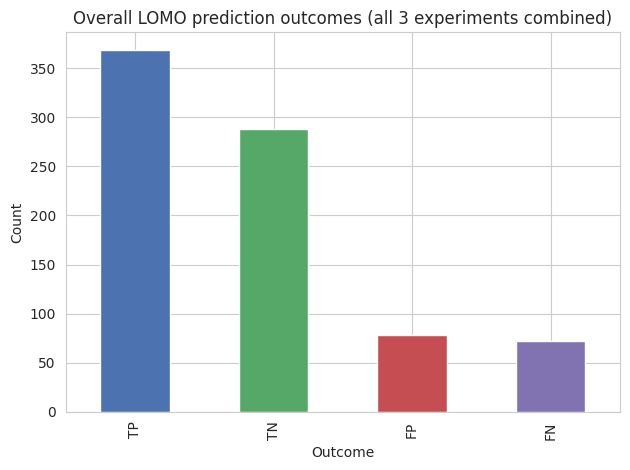

In [5]:
outcome_counts = preds["Outcome"].value_counts()
print(outcome_counts)
print(f"\nOverall accuracy: {(outcome_counts['TP']+outcome_counts['TN'])/len(preds):.4f}")

outcome_counts.plot(kind="bar", color=["#4C72B0","#55A868","#C44E52","#8172B2"])
plt.title("Overall LOMO prediction outcomes (all 3 experiments combined)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(BASE + "plot_outcome_counts.png", dpi=150)
plt.show()

In [6]:
print("=== False Negative Analysis ===")
fn = preds[preds["Outcome"] == "FN"]
print(f"Total FN: {len(fn)} ({len(fn)/len(preds)*100:.1f}% of all rows)\n")

fn_summary = []
for m in preds["Held_Out_Model"].unique():
    sub = preds[preds["Held_Out_Model"] == m]
    actual_hall = sub[sub["Actual_Hallucination"] == 1]
    fn_sub = sub[sub["Outcome"] == "FN"]
    rate = len(fn_sub) / len(actual_hall) * 100
    fn_summary.append({"Model": m, "FN": len(fn_sub), "Actual_Hallucinated": len(actual_hall), "FN_Rate_%": round(rate, 1)})
    print(f"  {m}: FN={len(fn_sub)} / actual_hallucinated={len(actual_hall)} -> FN rate = {rate:.1f}%")

fn_summary_df = pd.DataFrame(fn_summary)
fn_summary_df

=== False Negative Analysis ===
Total FN: 72 (8.9% of all rows)

  DeepSeek: FN=27 / actual_hallucinated=123 -> FN rate = 22.0%
  Groq: FN=21 / actual_hallucinated=158 -> FN rate = 13.3%
  OpenAI: FN=24 / actual_hallucinated=159 -> FN rate = 15.1%


,Model,FN,Actual_Hallucinated,FN_Rate_%
0,DeepSeek,27,123,22.0
1,Groq,21,158,13.3
2,OpenAI,24,159,15.1


In [7]:
print("=== False Positive Analysis ===")
fp = preds[preds["Outcome"] == "FP"]
print(f"Total FP: {len(fp)} ({len(fp)/len(preds)*100:.1f}% of all rows)\n")

fp_summary = []
for m in preds["Held_Out_Model"].unique():
    sub = preds[preds["Held_Out_Model"] == m]
    actual_nonhall = sub[sub["Actual_Hallucination"] == 0]
    fp_sub = sub[sub["Outcome"] == "FP"]
    rate = len(fp_sub) / len(actual_nonhall) * 100
    fp_summary.append({"Model": m, "FP": len(fp_sub), "Actual_NonHallucinated": len(actual_nonhall), "FP_Rate_%": round(rate, 1)})
    print(f"  {m}: FP={len(fp_sub)} / actual_nonhallucinated={len(actual_nonhall)} -> FP rate = {rate:.1f}%")

fp_summary_df = pd.DataFrame(fp_summary)
fp_summary_df

=== False Positive Analysis ===
Total FP: 78 (9.7% of all rows)

  DeepSeek: FP=36 / actual_nonhallucinated=147 -> FP rate = 24.5%
  Groq: FP=16 / actual_nonhallucinated=99 -> FP rate = 16.2%
  OpenAI: FP=26 / actual_nonhallucinated=120 -> FP rate = 21.7%


,Model,FP,Actual_NonHallucinated,FP_Rate_%
0,DeepSeek,36,147,24.5
1,Groq,16,99,16.2
2,OpenAI,26,120,21.7


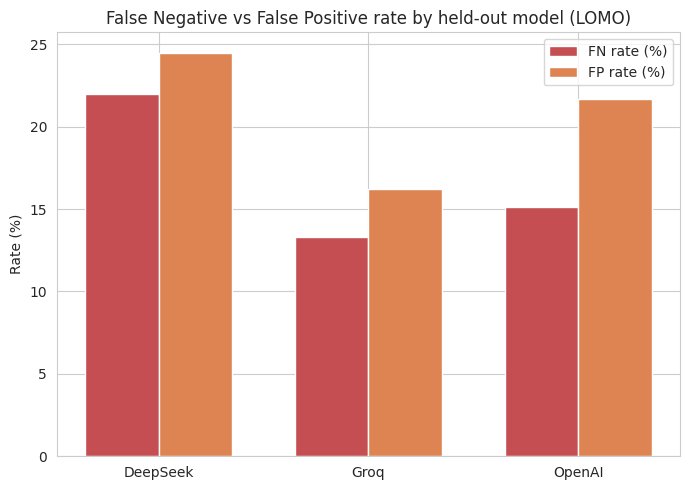

In [8]:
merged = fn_summary_df.merge(fp_summary_df, on="Model")
x = np.arange(len(merged))
width = 0.35

fig, ax = plt.subplots(figsize=(7,5))
ax.bar(x - width/2, merged["FN_Rate_%"], width, label="FN rate (%)", color="#C44E52")
ax.bar(x + width/2, merged["FP_Rate_%"], width, label="FP rate (%)", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(merged["Model"])
ax.set_ylabel("Rate (%)")
ax.set_title("False Negative vs False Positive rate by held-out model (LOMO)")
ax.legend()
plt.tight_layout()
plt.savefig(BASE + "plot_fn_fp_by_model.png", dpi=150)
plt.show()

Outcome                    FN  FP  TN  TP  Total  FN_Rate_%
Category                                                   
Misconceptions              2   8  55   5     70        2.9
Sociology                  10   9  33   4     56       17.9
Confusion: People           0   6   0  48     54        0.0
Health                      2   3  38   7     50        4.0
Indexical Error: Other      1   0   0  47     48        2.1
Indexical Error: Time       5   1   4  31     41       12.2
Fiction                     7   3   9  20     39       17.9
Law                         3   8   8  19     38        7.9
Misinformation              4   0   0  30     34       11.8
Economics                   1   1  25   0     27        3.7
Confusion: Places           1   8   0  14     23        4.3
Conspiracies                2   1  19   1     23        8.7
Indexical Error: Location   0   0   0  22     22        0.0
Psychology                  5   0   0  17     22       22.7
Distraction                 5   3  11   

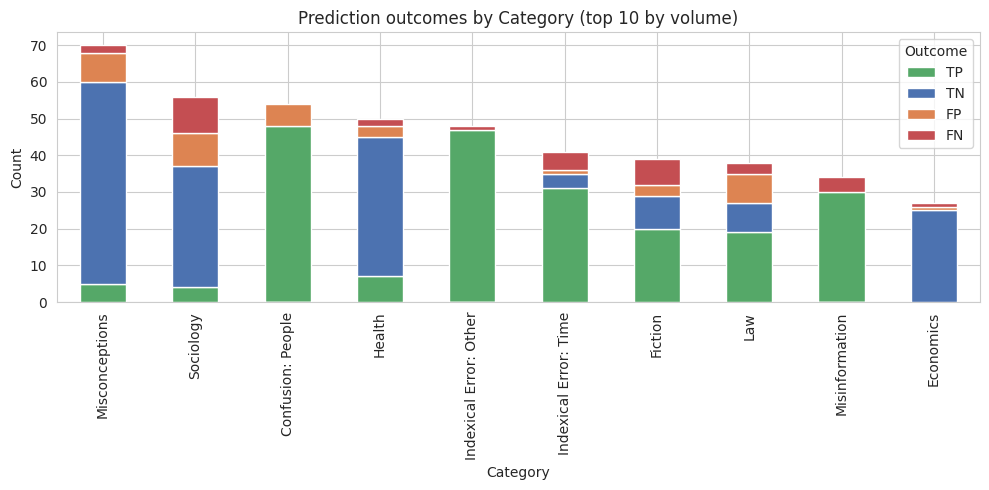

In [9]:
cat_analysis = preds.groupby(["Category", "Outcome"]).size().unstack(fill_value=0)
cat_analysis["Total"] = cat_analysis.sum(axis=1)
if "FN" in cat_analysis.columns:
    cat_analysis["FN_Rate_%"] = (cat_analysis["FN"] / cat_analysis["Total"] * 100).round(1)
cat_analysis = cat_analysis.sort_values("Total", ascending=False)
print(cat_analysis)

top_cats = cat_analysis.head(10)
top_cats[["TP","TN","FP","FN"]].plot(kind="bar", stacked=True, figsize=(10,5),
    color=["#55A868","#4C72B0","#DD8452","#C44E52"])
plt.title("Prediction outcomes by Category (top 10 by volume)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(BASE + "plot_by_category.png", dpi=150)
plt.show()

Outcome          FN  FP   TN   TP  Total  FN_Rate_%
Type                                               
Adversarial      36  34  152  157    379        9.5
Non-Adversarial  36  44  136  211    427        8.4


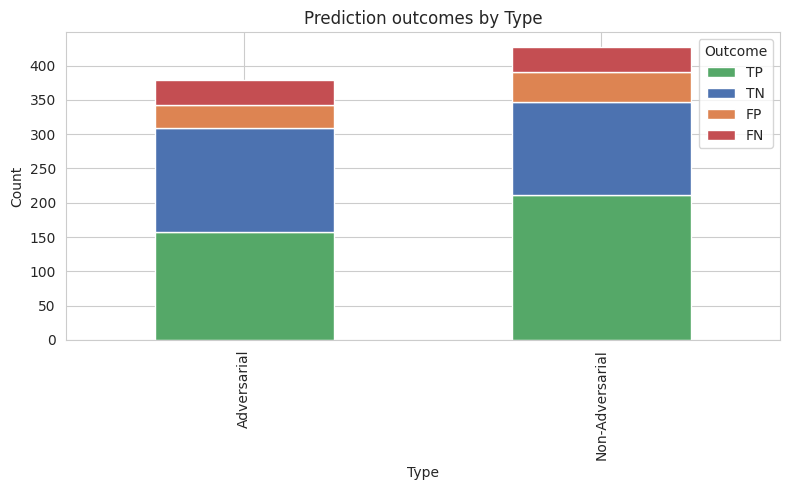

In [10]:
type_analysis = preds.groupby(["Type", "Outcome"]).size().unstack(fill_value=0)
type_analysis["Total"] = type_analysis.sum(axis=1)
if "FN" in type_analysis.columns:
    type_analysis["FN_Rate_%"] = (type_analysis["FN"] / type_analysis["Total"] * 100).round(1)
print(type_analysis)

type_analysis[["TP","TN","FP","FN"]].plot(kind="bar", stacked=True, figsize=(8,5),
    color=["#55A868","#4C72B0","#DD8452","#C44E52"])
plt.title("Prediction outcomes by Type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(BASE + "plot_by_type.png", dpi=150)
plt.show()

              mean        std  min    max
Outcome                                  
FN       35.250000  16.110315  1.0   87.0
FP       37.397436  21.387786  1.0   85.0
TN       34.135417  13.308418  5.0   72.0
TP       44.176630  17.604458  1.0  179.0


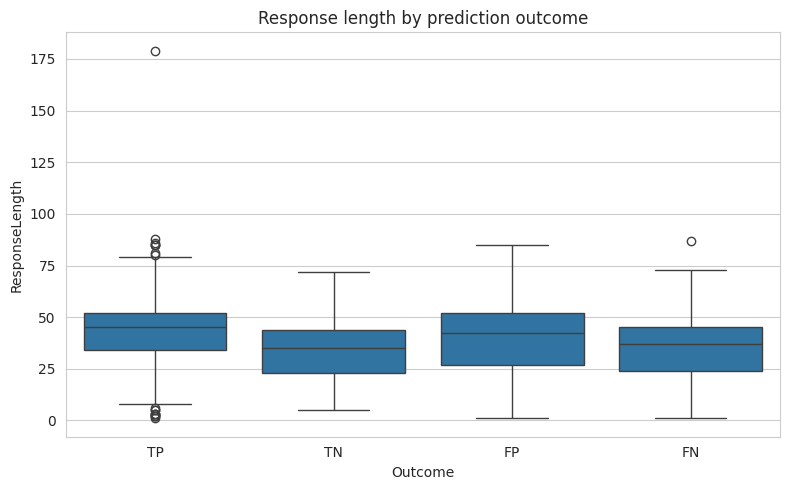

In [11]:
print(preds.groupby("Outcome")["ResponseLength"].describe()[["mean","std","min","max"]])

plt.figure(figsize=(8,5))
sns.boxplot(data=preds, x="Outcome", y="ResponseLength", order=["TP","TN","FP","FN"])
plt.title("Response length by prediction outcome")
plt.tight_layout()
plt.savefig(BASE + "plot_response_length.png", dpi=150)
plt.show()

              mean       std  min   max
Outcome                                
FN       10.013889  4.332950  4.0  37.0
FP       14.576923  9.856792  4.0  50.0
TN        9.638889  3.800992  3.0  20.0
TP       13.861413  7.533745  3.0  45.0


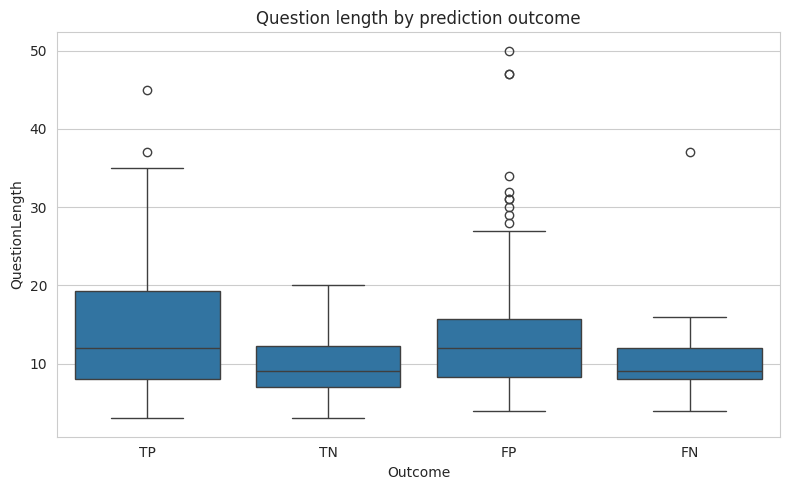

In [12]:
print(preds.groupby("Outcome")["QuestionLength"].describe()[["mean","std","min","max"]])

plt.figure(figsize=(8,5))
sns.boxplot(data=preds, x="Outcome", y="QuestionLength", order=["TP","TN","FP","FN"])
plt.title("Question length by prediction outcome")
plt.tight_layout()
plt.savefig(BASE + "plot_question_length.png", dpi=150)
plt.show()

             mean       std       min       max
Outcome                                        
FN       0.227409  0.229567 -0.041154  0.609673
FP       0.885739  0.042326  0.831901  1.000000
TN       0.884012  0.033703  0.830584  0.970118
TP       0.226037  0.199176 -0.103052  0.610988


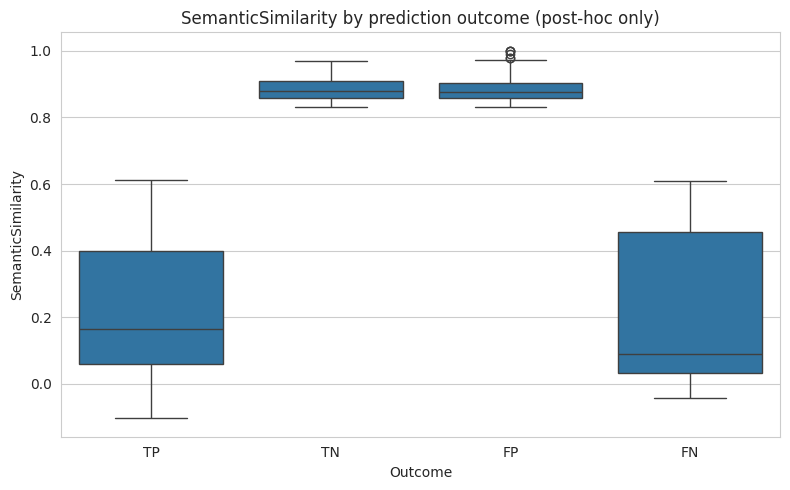


FN mean SemanticSimilarity: 0.2274
TP mean SemanticSimilarity: 0.2260


In [13]:
print(preds.groupby("Outcome")["SemanticSimilarity"].describe()[["mean","std","min","max"]])

plt.figure(figsize=(8,5))
sns.boxplot(data=preds, x="Outcome", y="SemanticSimilarity", order=["TP","TN","FP","FN"])
plt.title("SemanticSimilarity by prediction outcome (post-hoc only)")
plt.tight_layout()
plt.savefig(BASE + "plot_semantic_similarity.png", dpi=150)
plt.show()

fn_sim = preds[preds["Outcome"]=="FN"]["SemanticSimilarity"]
tp_sim = preds[preds["Outcome"]=="TP"]["SemanticSimilarity"]
print(f"\nFN mean SemanticSimilarity: {fn_sim.mean():.4f}")
print(f"TP mean SemanticSimilarity: {tp_sim.mean():.4f}")

             mean       std       min       max
Outcome                                        
FN       0.833778  0.023929  0.781422  0.867257
FP       0.924478  0.026265  0.902467  1.000000
TN       0.922528  0.017364  0.902315  0.995548
TP       0.834196  0.022740  0.779966  0.867396


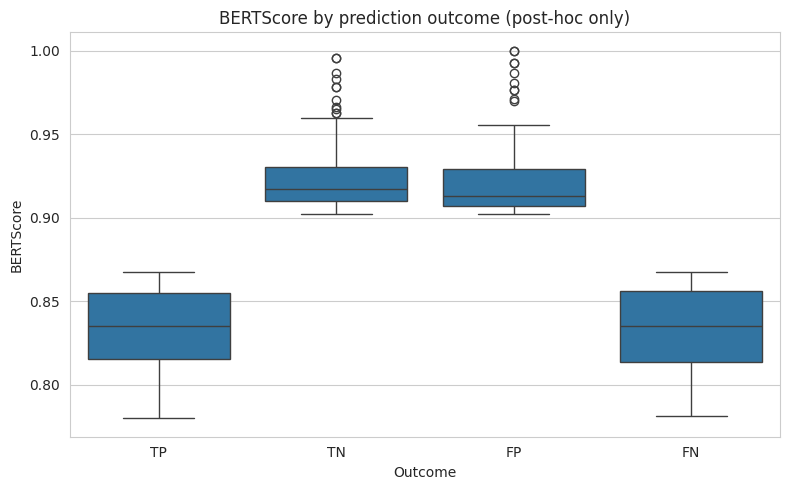


FN mean BERTScore: 0.8338
TP mean BERTScore: 0.8342


In [14]:
print(preds.groupby("Outcome")["BERTScore"].describe()[["mean","std","min","max"]])

plt.figure(figsize=(8,5))
sns.boxplot(data=preds, x="Outcome", y="BERTScore", order=["TP","TN","FP","FN"])
plt.title("BERTScore by prediction outcome (post-hoc only)")
plt.tight_layout()
plt.savefig(BASE + "plot_bertscore.png", dpi=150)
plt.show()

fn_bert = preds[preds["Outcome"]=="FN"]["BERTScore"]
tp_bert = preds[preds["Outcome"]=="TP"]["BERTScore"]
print(f"\nFN mean BERTScore: {fn_bert.mean():.4f}")
print(f"TP mean BERTScore: {tp_bert.mean():.4f}")

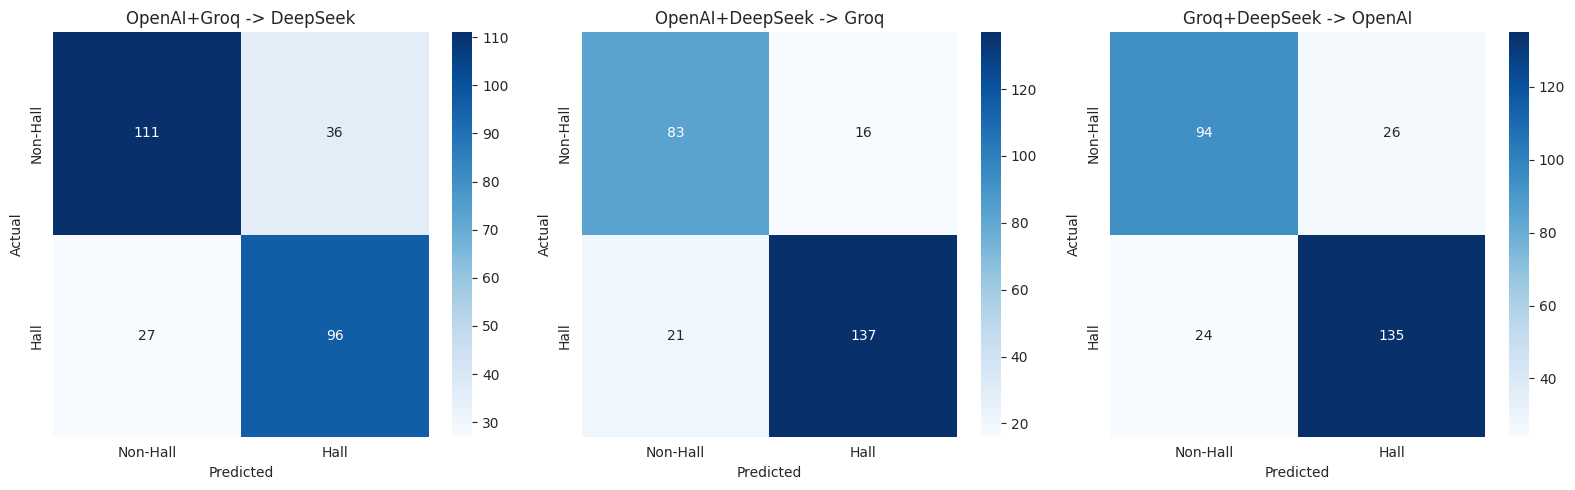

In [15]:
experiments = preds["LOMO_Experiment"].unique()

fig, axes = plt.subplots(1, 3, figsize=(16,5))
for ax, exp in zip(axes, experiments):
    sub = preds[preds["LOMO_Experiment"] == exp]
    cm = confusion_matrix(sub["Actual_Hallucination"], sub["Predicted_Hallucination"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Non-Hall","Hall"], yticklabels=["Non-Hall","Hall"])
    ax.set_title(exp)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(BASE + "plot_lomo_confusion_matrices.png", dpi=150)
plt.show()

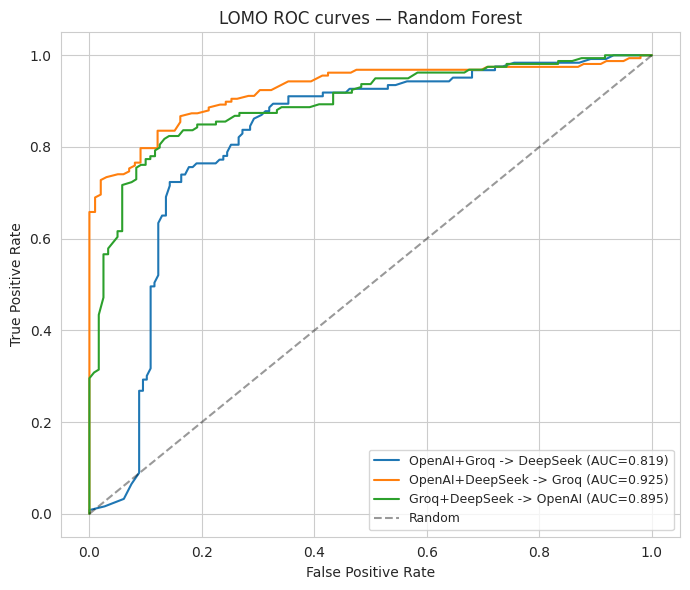

In [16]:
plt.figure(figsize=(7,6))
for exp in experiments:
    sub = preds[preds["LOMO_Experiment"] == exp]
    fpr, tpr, _ = roc_curve(sub["Actual_Hallucination"], sub["Predicted_Probability"])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{exp} (AUC={roc_auc:.3f})")

plt.plot([0,1], [0,1], "k--", alpha=0.4, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LOMO ROC curves — Random Forest")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(BASE + "plot_lomo_roc_curves.png", dpi=150)
plt.show()

Test_Model          DeepSeek    Groq  OpenAI
Feature                                     
AverageWordLength     0.1500  0.1677  0.1583
Category              0.3509  0.3063  0.2977
QuestionLength        0.1681  0.1559  0.1689
ResponseCharacters    0.1725  0.1910  0.1952
ResponseLength        0.1314  0.1498  0.1513
Type                  0.0271  0.0294  0.0286


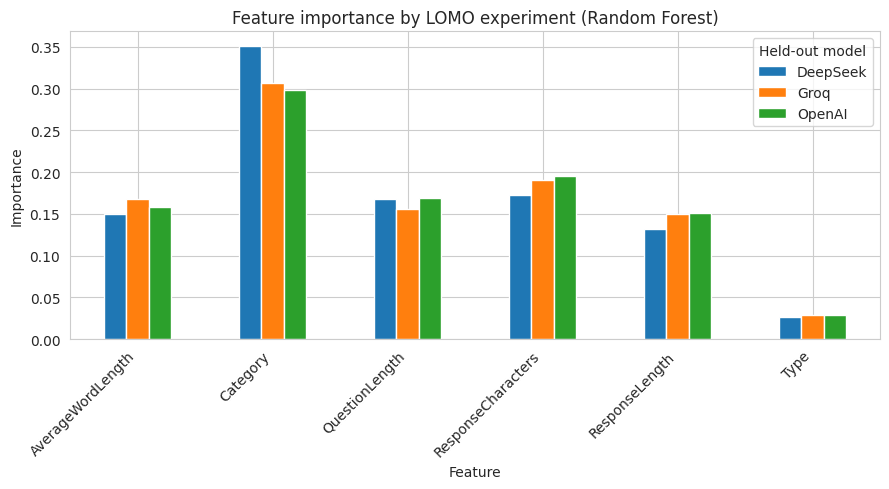

In [17]:
CAT_FEATURES = ["Category", "Type"]
NUM_FEATURES = ["ResponseLength", "QuestionLength", "ResponseCharacters", "AverageWordLength"]
TARGET = "Hallucination"

clean_df = pd.read_csv(BASE + "factcheck_clean_dataset.csv")

LOMO_SETS = [
    (["OpenAI","Groq"], "DeepSeek"),
    (["OpenAI","DeepSeek"], "Groq"),
    (["Groq","DeepSeek"], "OpenAI"),
]

importance_records = []
for train_models, test_model in LOMO_SETS:
    train_df = clean_df[clean_df["Model"].isin(train_models)].copy()

    for col in CAT_FEATURES:
        le = LabelEncoder()
        train_df[col+"_enc"] = le.fit_transform(train_df[col].astype(str))

    scaler = StandardScaler()
    train_num = scaler.fit_transform(train_df[NUM_FEATURES])
    train_cat = train_df[[c+"_enc" for c in CAT_FEATURES]].values
    X_train = np.hstack([train_cat, train_num])
    y_train = train_df[TARGET].values

    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X_train, y_train)

    feat_names = CAT_FEATURES + NUM_FEATURES
    for name, imp in zip(feat_names, clf.feature_importances_):
        importance_records.append({"Test_Model": test_model, "Feature": name, "Importance": imp})

imp_df = pd.DataFrame(importance_records)
pivot = imp_df.pivot(index="Feature", columns="Test_Model", values="Importance")
print(pivot.round(4))

pivot.plot(kind="bar", figsize=(9,5))
plt.title("Feature importance by LOMO experiment (Random Forest)")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Held-out model")
plt.tight_layout()
plt.savefig(BASE + "plot_feature_importance.png", dpi=150)
plt.show()

  Held_Out_Model  Accuracy        F1   ROC_AUC
0       DeepSeek  0.766667  0.752941  0.818566
1           Groq  0.856031  0.881029  0.925233
2         OpenAI  0.820789  0.843750  0.895152


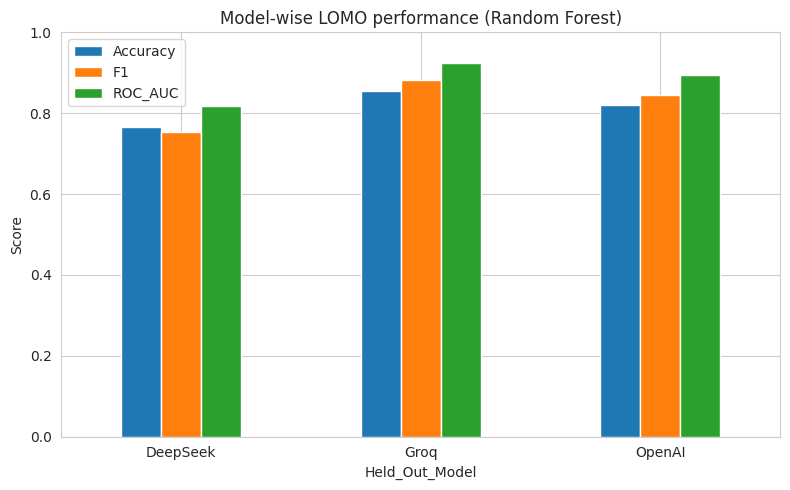

In [18]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

perf_records = []
for exp in experiments:
    sub = preds[preds["LOMO_Experiment"] == exp]
    perf_records.append({
        "Held_Out_Model": sub["Held_Out_Model"].iloc[0],
        "Accuracy": accuracy_score(sub["Actual_Hallucination"], sub["Predicted_Hallucination"]),
        "F1": f1_score(sub["Actual_Hallucination"], sub["Predicted_Hallucination"]),
        "ROC_AUC": roc_auc_score(sub["Actual_Hallucination"], sub["Predicted_Probability"]),
    })

perf_df = pd.DataFrame(perf_records)
print(perf_df)

perf_df.set_index("Held_Out_Model")[["Accuracy","F1","ROC_AUC"]].plot(kind="bar", figsize=(8,5))
plt.title("Model-wise LOMO performance (Random Forest)")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(BASE + "plot_modelwise_performance.png", dpi=150)
plt.show()

In [19]:
fn_summary_df.to_csv(BASE + "day3_fn_summary.csv", index=False)
fp_summary_df.to_csv(BASE + "day3_fp_summary.csv", index=False)
cat_analysis.to_csv(BASE + "day3_category_analysis.csv")
type_analysis.to_csv(BASE + "day3_type_analysis.csv")
perf_df.to_csv(BASE + "day3_modelwise_performance.csv", index=False)
pivot.to_csv(BASE + "day3_feature_importance.csv")

print("All Day 3 error-analysis outputs saved to:", BASE)

All Day 3 error-analysis outputs saved to: /content/drive/MyDrive/factcheckAI/outputs/
